# Handwritten Digit Generation Using GAN on MNIST Dataset

## Objective:
To implement and train a simple Generative Adversarial Network (GAN) using TensorFlow (Keras API) to generate handwritten digit images that resemble the MNIST dataset. This mini-assignment aims to strengthen your understanding of adversarial learning and generative modeling.

In [1]:
# Data Handling and Manipulation
import pandas as pd
import numpy as np
import os

# Visualization
import matplotlib.pyplot as plt

# Model Building
import tensorflow as tf
from tensorflow.keras import layers

# Load and Preprocessing

## Import Dataset

In [23]:
# Load Dataset
(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

print("Original shape     :", X_train.shape)

# Normalize the data to the range [-1, 1] and reshape to (28, 28, 1).
X_train = (X_train.astype("float32") - 127.5) / 127.5
X_train = np.expand_dims(X_train, axis=-1)

print("After preprocessing:", X_train.shape)
print("Pixel range        : [{:.1f}, {:.1f}]".format(X_train.min(), X_train.max()))

BUFFER_SIZE = 60000
BATCH_SIZE  = 256

dataset = (
    tf.data.Dataset
    .from_tensor_slices(X_train)
    .shuffle(BUFFER_SIZE)
    .batch(BATCH_SIZE, drop_remainder=True)
)

print("Batches per epoch  :", len(list(dataset)))

Original shape     : (60000, 28, 28)
After preprocessing: (60000, 28, 28, 1)
Pixel range        : [-1.0, 1.0]
Batches per epoch  : 234


## Display Sample Images

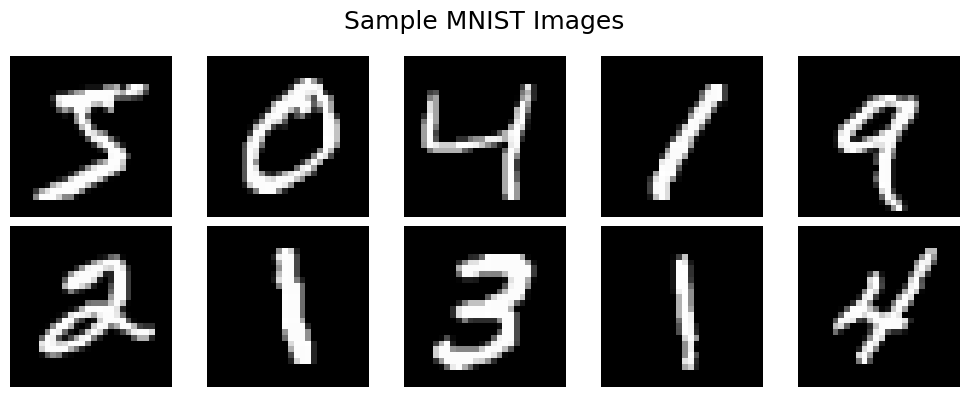

In [20]:
# Display Few Sample Images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i, :, :, 0] * 0.5 + 0.5, cmap="gray")
    ax.axis("off")
plt.suptitle("Sample MNIST Images", fontsize=18)
plt.tight_layout()
plt.show()

# 3. Model Design

## Generator

*Layers: Dense --> BatchNormalization --> LeakyReLU --> Conv2DTranspose --> Output (Tanh)*

In [24]:
# Build Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(7 * 7 * 256, use_bias=False, input_shape=(100,)),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Reshape((7, 7, 256)),

        layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),

        layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding="same",
                               use_bias=False, activation="tanh"),
    ], name="Generator")
    return model

generator = build_generator()
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12544)          │     1,254,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12544)          │        50,176 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 7, 7, 128)      │       819,200 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 14, 14, 64)     │       204,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │         1,600 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,330,944 (8.89 MB)

 Trainable params: 2,305,472 (8.79 MB)

 Non-trainable params: 25,472 (99.50 KB)

## Discriminator

*Layers: Conv2D --> LeakyReLU --> Dropout --> Flatten--> Dense (Sigmoid)*

In [25]:
# Build Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Conv2D(64, (5, 5), strides=(2, 2), padding="same",
                      input_shape=[28, 28, 1]),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Conv2D(128, (5, 5), strides=(2, 2), padding="same"),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),

        layers.Flatten(),

        layers.Dense(1, activation="sigmoid"),
    ], name="Discriminator")
    return model

discriminator = build_discriminator()
discriminator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │         6,273 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 212,865 (831.50 KB)

 Trainable params: 212,865 (831.50 KB)

 Non-trainable params: 0 (0.00 B)

## Loss Functions and Optimizers

In [27]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=False)

def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    return real_loss + fake_loss

def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

gen_optimizer  = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

## Training Setup

In [30]:
EPOCHS    = 20
NOISE_DIM = 100
NUM_EXAMPLES = 16

seed = tf.random.normal([NUM_EXAMPLES, NOISE_DIM])

gen_losses  = []
disc_losses = []

os.makedirs("generated_images", exist_ok=True)

In [31]:
def generate_and_show_images(model, epoch, test_input):
    """Generate images from the fixed seed and display them in the notebook."""

    predictions = model(test_input, training=False)

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle(f"Generated Images — Epoch {epoch}", fontsize=13)

    for i, ax in enumerate(axes.flat):
        img = predictions[i, :, :, 0].numpy() * 0.5 + 0.5
        ax.imshow(img, cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"generated_images/epoch_{epoch:02d}.png", dpi=80, bbox_inches="tight")
    plt.show()
    plt.close()

In [32]:
@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, NOISE_DIM])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise, training=True)

        real_output = discriminator(real_images, training=True)
        fake_output = discriminator(fake_images, training=True)

        g_loss = generator_loss(fake_output)
        d_loss = discriminator_loss(real_output, fake_output)

    gen_grads  = gen_tape.gradient(g_loss,  generator.trainable_variables)
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)

    gen_optimizer.apply_gradients(zip(gen_grads,  generator.trainable_variables))
    disc_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))

    return g_loss, d_loss

## Training Loop

Epoch  1/20  |  Gen Loss: 0.6762  |  Disc Loss: 1.3078
Epoch  2/20  |  Gen Loss: 0.7312  |  Disc Loss: 1.3445
Epoch  3/20  |  Gen Loss: 0.7465  |  Disc Loss: 1.3399
Epoch  4/20  |  Gen Loss: 0.7686  |  Disc Loss: 1.3088
Epoch  5/20  |  Gen Loss: 0.7875  |  Disc Loss: 1.3016


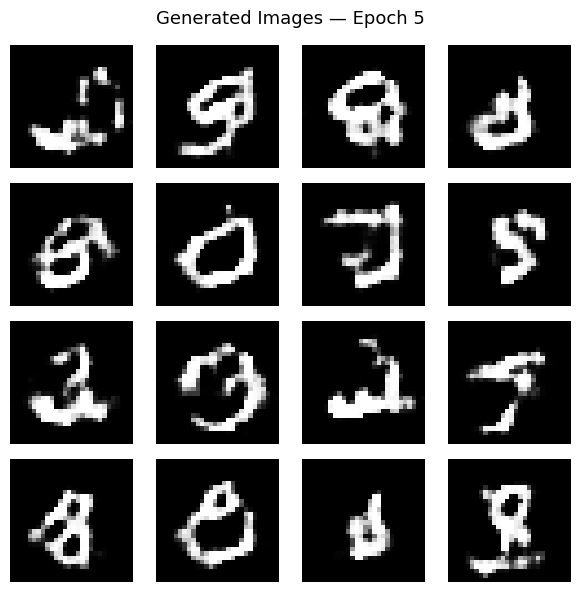

Epoch  6/20  |  Gen Loss: 0.7883  |  Disc Loss: 1.2991
Epoch  7/20  |  Gen Loss: 0.7686  |  Disc Loss: 1.3298
Epoch  8/20  |  Gen Loss: 0.7701  |  Disc Loss: 1.3236
Epoch  9/20  |  Gen Loss: 0.7566  |  Disc Loss: 1.3362
Epoch 10/20  |  Gen Loss: 0.7571  |  Disc Loss: 1.3306


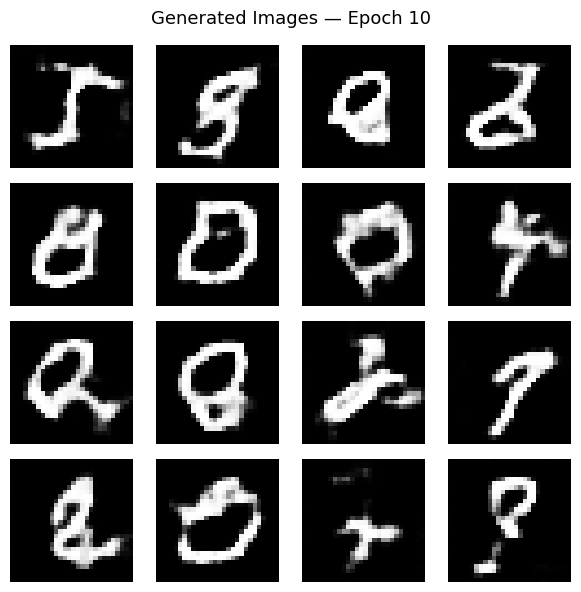

Epoch 11/20  |  Gen Loss: 0.7657  |  Disc Loss: 1.3266
Epoch 12/20  |  Gen Loss: 0.7642  |  Disc Loss: 1.3261
Epoch 13/20  |  Gen Loss: 0.7692  |  Disc Loss: 1.3206
Epoch 14/20  |  Gen Loss: 0.7759  |  Disc Loss: 1.3152
Epoch 15/20  |  Gen Loss: 0.7805  |  Disc Loss: 1.3130


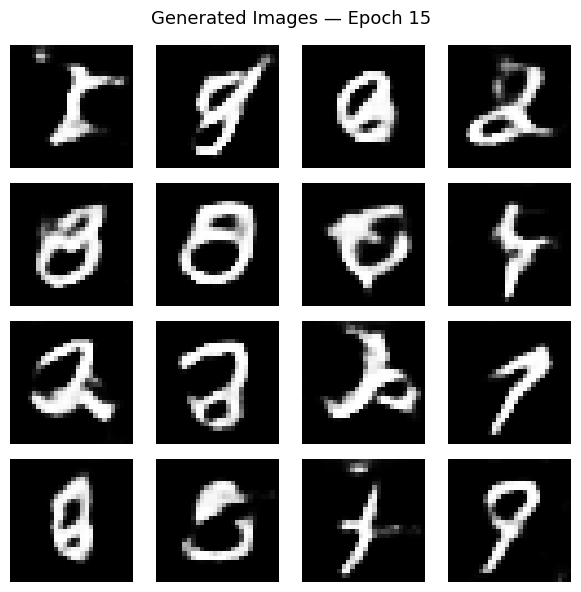

Epoch 16/20  |  Gen Loss: 0.7833  |  Disc Loss: 1.3088
Epoch 17/20  |  Gen Loss: 0.7892  |  Disc Loss: 1.3083
Epoch 18/20  |  Gen Loss: 0.7944  |  Disc Loss: 1.3030
Epoch 19/20  |  Gen Loss: 0.7968  |  Disc Loss: 1.3033
Epoch 20/20  |  Gen Loss: 0.7993  |  Disc Loss: 1.2982


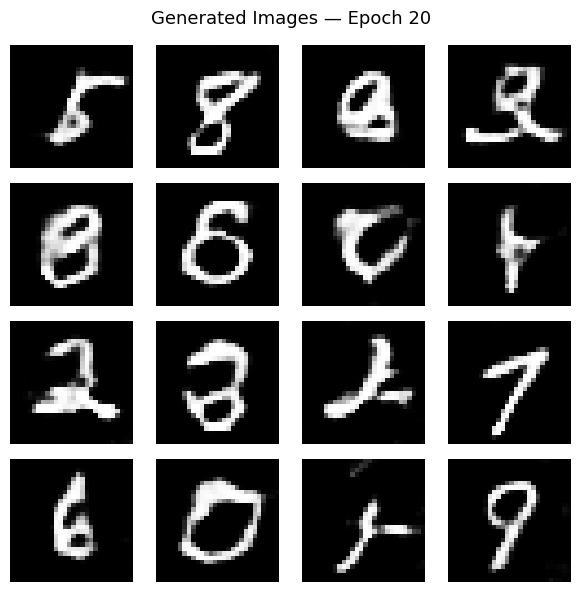

In [33]:
def train(dataset, epochs):

    for epoch in range(epochs):
        epoch_gen_loss  = []
        epoch_disc_loss = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_loss.append(float(g_loss))
            epoch_disc_loss.append(float(d_loss))

        avg_g = float(np.mean(epoch_gen_loss))
        avg_d = float(np.mean(epoch_disc_loss))
        gen_losses.append(avg_g)
        disc_losses.append(avg_d)

        print(f"Epoch {epoch+1:2d}/{epochs}  |  Gen Loss: {avg_g:.4f}  |  Disc Loss: {avg_d:.4f}")

      # Generate images every 10 epochs
        if (epoch + 1) % 5 == 0 or (epoch + 1) == epochs:
            generate_and_show_images(generator, epoch + 1, seed)

train(dataset, EPOCHS)

## Plot Training Loss Curve

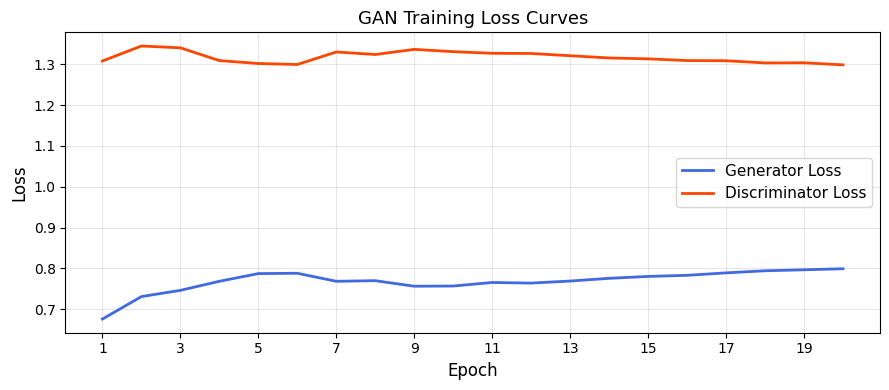

In [34]:
# Plot loss curves for generator and discriminator
plt.figure(figsize=(9, 4))
plt.plot(range(1, EPOCHS + 1), gen_losses,  label="Generator Loss",     color="royalblue",  linewidth=2)
plt.plot(range(1, EPOCHS + 1), disc_losses, label="Discriminator Loss", color="orangered",  linewidth=2)
plt.xlabel("Epoch",  fontsize=12)
plt.ylabel("Loss",   fontsize=12)
plt.title("GAN Training Loss Curves", fontsize=13)
plt.legend(fontsize=11)
plt.xticks(range(1, EPOCHS + 1, 2))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("generated_images/loss_curves.png", dpi=100, bbox_inches="tight")
plt.show()

# Conclusion:
This project shows how a GAN can learn to generate handwritten digits starting from random noise. The generator improves step by step by trying to fool the discriminator, while the discriminator learns to better detect fake images. This competition helps both models improve over time.

At the beginning, the generated images were unclear and looked like noise. After training for multiple epochs, the model started producing digits that are more structured and closer to real handwritten numbers. By around the final epochs, many outputs became recognizable, though some were still imperfect or distorted.

One important takeaway is that GAN training is not stable. The losses do not always decrease smoothly, and the balance between generator and discriminator is difficult to maintain. Small changes in parameters can affect the results a lot.

Overall, the model was able to learn meaningful patterns from the dataset and generate realistic digit like images. This shows the potential of GANs for image generation tasks, even though they require careful tuning and patience during training.